In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
with zipfile.ZipFile("SMS Spam Collection Dataset.zip","r") as zip_ref:
    zip_ref.extractall()

In [21]:
df = pd.read_csv("spam.csv",encoding="latin-1")

In [22]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [23]:
df = df[["v1","v2"]]

df.columns=["Label","Message"]

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [25]:
df.shape

(5572, 2)

In [26]:
df.isnull().sum()

,0
Label,0
Message,0


In [27]:
df = df.dropna()

In [28]:
df["Label"].value_counts()

,count
Label,
ham,4825
spam,747


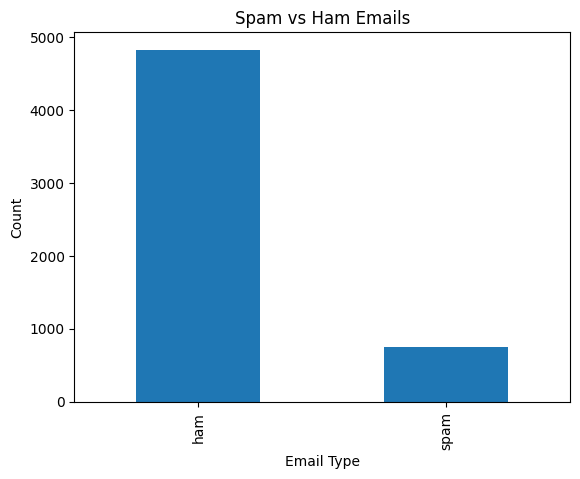

In [29]:
df["Label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Emails")

plt.xlabel("Email Type")

plt.ylabel("Count")

plt.show()

In [30]:
df["Message"] = df["Message"].str.lower()

df["Message"] = df["Message"].str.replace(r"http\S+","",regex=True)

df["Message"] = df["Message"].str.replace(r"[^a-zA-Z ]","",regex=True)

df["Message"] = df["Message"].str.replace(r"\s+"," ",regex=True)

In [31]:
X = df["Message"]

y = df["Label"]

In [32]:
vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(X)

In [33]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [35]:
y_pred = model.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.968609865470852


In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [38]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[965   0]
 [ 35 115]]


In [39]:
email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

print(prediction)

['spam']


In [40]:
email = [
    "Hi team, please attend today's project meeting at 2 PM."
]

email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

print(prediction)

['ham']


In [41]:
print("========== Spam Analysis Report ==========")

print("Total Emails :",len(df))

print("Spam Emails :",len(df[df["Label"]=="spam"]))

print("Ham Emails :",len(df[df["Label"]=="ham"]))

print("Model Accuracy :",round(accuracy*100,2),"%")

========== Spam Analysis Report ==========
Total Emails : 5572
Spam Emails : 747
Ham Emails : 4825
Model Accuracy : 96.86 %
